In [5]:
# Install (if needed)
!pip install -q datasets tensorflow scikit-learn

In [6]:
import numpy as np
import matplotlib.pyplot as plt
from datasets import load_dataset
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, SimpleRNN, Dense
from sklearn.metrics import classification_report

In [18]:
ds = load_dataset("fancyzhx/ag_news")

train_data = ds["train"]
test_data = ds["test"]

print(train_data[0])

{'text': "Wall St. Bears Claw Back Into the Black (Reuters) Reuters - Short-sellers, Wall Street's dwindling\\band of ultra-cynics, are seeing green again.", 'label': 2}


In [8]:
X_train = train_data["text"]
y_train = np.array(train_data["label"])

X_test = test_data["text"]
y_test = np.array(test_data["label"])

In [9]:
vocab_size = 10000
max_length = 100

tokenizer = Tokenizer(num_words=vocab_size, oov_token="<OOV>")
tokenizer.fit_on_texts(X_train)

X_train_seq = tokenizer.texts_to_sequences(X_train)
X_test_seq = tokenizer.texts_to_sequences(X_test)

X_train_pad = pad_sequences(
    X_train_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

X_test_pad = pad_sequences(
    X_test_seq,
    maxlen=max_length,
    padding="post",
    truncating="post"
)

In [10]:
model = Sequential([
    Embedding(vocab_size, 128, input_length=max_length),
    SimpleRNN(64),
    Dense(64, activation="relu"),
    Dense(4, activation="softmax")
])

model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ embedding (Embedding)           │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn (SimpleRNN)          │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ ?                      │   0 (unbuilt) │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ ?                      │   0 (unbuilt) │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 0 (0.00 B)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 0 (0.00 B)

In [11]:
model.compile(
    optimizer="adam",
    loss="sparse_categorical_crossentropy",
    metrics=["accuracy"]
)

In [12]:
history = model.fit(
    X_train_pad,
    y_train,
    epochs=5,
    batch_size=64,
    validation_split=0.2
)

Epoch 1/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 20s 11ms/step - accuracy: 0.5247 - loss: 1.1306 - val_accuracy: 0.6140 - val_loss: 1.0175
Epoch 2/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6540 - loss: 0.9326 - val_accuracy: 0.6071 - val_loss: 0.9827
Epoch 3/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.6571 - loss: 0.8671 - val_accuracy: 0.6090 - val_loss: 0.9449
Epoch 4/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 16s 10ms/step - accuracy: 0.4976 - loss: 1.1274 - val_accuracy: 0.4878 - val_loss: 1.1733
Epoch 5/5
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 15s 10ms/step - accuracy: 0.5939 - loss: 0.9820 - val_accuracy: 0.6385 - val_loss: 0.8630


In [13]:
loss, accuracy = model.evaluate(X_test_pad, y_test)

print("Test Accuracy:", accuracy)

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.6536 - loss: 0.8458
Test Accuracy: 0.6535526514053345


In [14]:
pred = model.predict(X_test_pad)
pred_labels = np.argmax(pred, axis=1)

print(classification_report(y_test, pred_labels))

238/238 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step
              precision    recall  f1-score   support

           0       0.65      0.57      0.61      1900
           1       0.82      0.92      0.86      1900
           2       0.51      0.58      0.54      1900
           3       0.64      0.55      0.59      1900

    accuracy                           0.65      7600
   macro avg       0.65      0.65      0.65      7600
weighted avg       0.65      0.65      0.65      7600



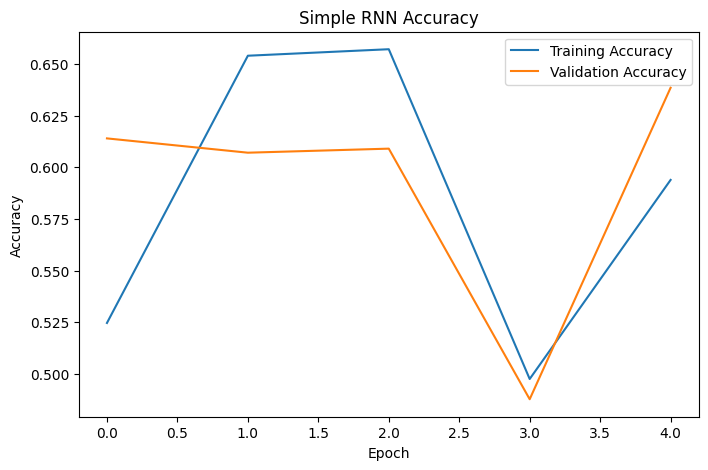

In [15]:
plt.figure(figsize=(8,5))
plt.plot(history.history["accuracy"], label="Training Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.title("Simple RNN Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

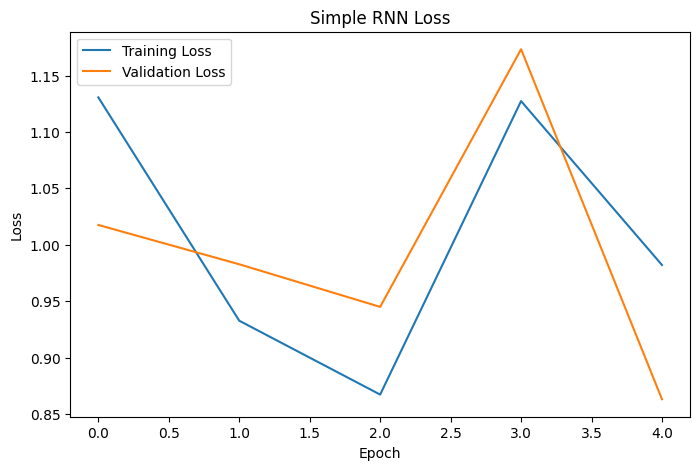

In [16]:
plt.figure(figsize=(8,5))
plt.plot(history.history["loss"], label="Training Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.title("Simple RNN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
plt.show()

In [17]:
labels = {
    0: "World",
    1: "Sports",
    2: "Business",
    3: "Sci/Tech"
}

news = [
    "India defeated Australia in the cricket final.",
    "Apple launches a new AI-powered iPhone.",
    "NASA discovers a new planet.",
    "Stock market reaches a record high."
]

seq = tokenizer.texts_to_sequences(news)
pad = pad_sequences(seq, maxlen=max_length, padding="post")

pred = model.predict(pad)

for text, p in zip(news, pred):
    print("News:", text)
    print("Category:", labels[np.argmax(p)])
    print()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 326ms/step
News: India defeated Australia in the cricket final.
Category: World

News: Apple launches a new AI-powered iPhone.
Category: Sci/Tech

News: NASA discovers a new planet.
Category: Sci/Tech

News: Stock market reaches a record high.
Category: World

